# Suresh et al. (2025) ACI 核心实验复现（SPS-UK）

论文：V. Suresh et al., **Mamba based adaptive conformal inference for probabilistic short-term load forecasting**, *Knowledge-Based Systems* 328 (2025) 114222.

这不是 Table VI 的数值级复现。原论文使用 Tamil Nadu 区域小时负荷，而公开代码和数据并未随文提供。这里使用本仓库已有 **SPS-UK** 数据，只复现最核心的实验链：

```text
历史负荷 → LSTM 点预测 → Calibration 残差 → Static Split CP → ACI → Coverage / MIW / Winkler
```

为了与论文的 **one-hour-ahead** 任务一致，SPS-UK 30 min demand 重采样为 1 h。本 Notebook 不使用 PV/weather。

关键复现假设：LSTM lookback=24 h；ACI `gamma=0.01`。论文未明确报告这两个数值。

In [1]:
from pathlib import Path
from zipfile import ZipFile
import math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cpu


## 1. 读取 SPS-UK demand

数据直接复用上一项复现中的：

`papers/2024-smartgridcomm-conformal-mlpf/data/SPS-UK_dataset.zip`

In [2]:
def find_sps_zip():
    candidates = [
        Path("data/SPS-UK_dataset.zip"),
        Path("../2024-smartgridcomm-conformal-mlpf/data/SPS-UK_dataset.zip"),
        Path("papers/2024-smartgridcomm-conformal-mlpf/data/SPS-UK_dataset.zip"),
        Path("../../papers/2024-smartgridcomm-conformal-mlpf/data/SPS-UK_dataset.zip"),
    ]
    for p in candidates:
        p = p.resolve()
        if p.exists():
            return p
    roots = [Path.cwd().resolve()] + list(Path.cwd().resolve().parents[:3])
    for root in roots:
        m = list(root.glob("**/SPS-UK_dataset.zip"))
        if m:
            return m[0]
    raise FileNotFoundError("SPS-UK_dataset.zip not found")

def pick_datetime_column(df):
    preferred = [c for c in df.columns if any(k in c.lower() for k in ("datetime","timestamp","date","time"))]
    for c in preferred + list(df.columns):
        parsed = pd.to_datetime(df[c], errors="coerce")
        if parsed.notna().mean() > 0.9:
            return c
    raise ValueError("No datetime column found")

def pick_numeric_column(df):
    nums = list(df.select_dtypes(include=[np.number]).columns)
    named = [c for c in nums if any(k in c.lower() for k in ("demand","power","mw"))]
    if named:
        return named[0]
    if nums:
        return nums[0]
    raise ValueError("No numeric demand column found")

zip_path = find_sps_zip()
print("dataset:", zip_path)

with ZipFile(zip_path) as zf:
    members = {Path(n).name:n for n in zf.namelist()}
    def read_member(name):
        if name not in members:
            raise FileNotFoundError(name)
        with zf.open(members[name]) as f:
            return pd.read_csv(f)

    train = read_member("demand_train_set4.csv")
    try:
        test = read_member("demand_test_set4.csv")
        raw = pd.concat([train, test], ignore_index=True)
    except FileNotFoundError:
        raw = train.copy()

dt_col = pick_datetime_column(raw)
raw[dt_col] = pd.to_datetime(raw[dt_col], errors="coerce")
raw = raw.dropna(subset=[dt_col]).sort_values(dt_col).drop_duplicates(dt_col)
demand_col = pick_numeric_column(raw)

demand = raw[[dt_col, demand_col]].rename(columns={dt_col:"timestamp", demand_col:"demand_mw"})
demand = demand.set_index("timestamp").sort_index()
print("raw:", demand.index.min(), "->", demand.index.max(), "rows=", len(demand))
display(demand.head())

dataset: /home/runner/work/paper-reproductions/paper-reproductions/papers/2024-smartgridcomm-conformal-mlpf/data/SPS-UK_dataset.zip
raw: 2017-11-03 00:00:00 -> 2020-07-02 23:30:00 rows= 46704


,demand_mw
timestamp,
2017-11-03 00:00:00,2.19
2017-11-03 00:30:00,2.14
2017-11-03 01:00:00,2.01
2017-11-03 01:30:00,1.87
2017-11-03 02:00:00,1.86


## 2. 30 min → 1 h，并加入日历特征

Suresh et al. 是 one-hour-ahead。这里对 30 min 功率取小时均值。

hourly: 2017-11-03 00:00:00 -> 2020-07-02 23:00:00 rows= 23352


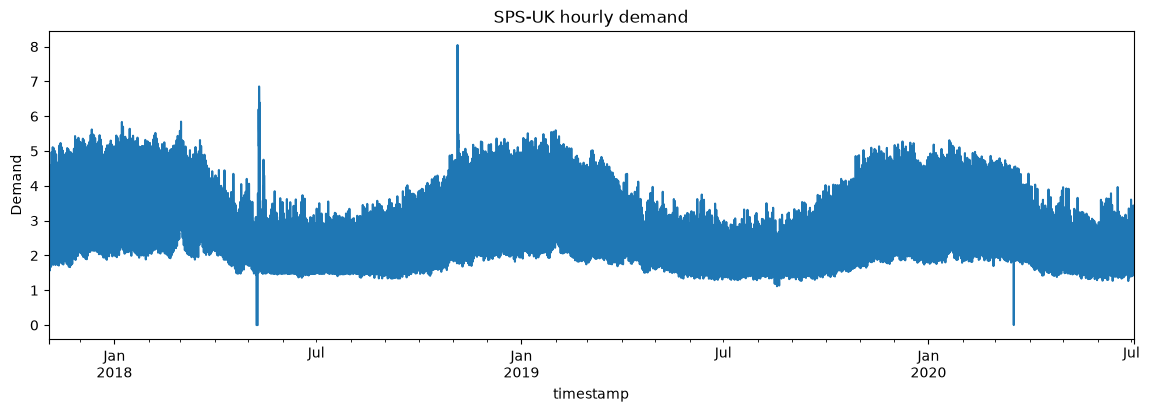

In [3]:
hourly = demand.resample("1h").mean().interpolate(limit=2)
ts = hourly.index
hour = ts.hour
dow = ts.dayofweek
month = ts.month
hourly["hour_sin"] = np.sin(2*np.pi*hour/24)
hourly["hour_cos"] = np.cos(2*np.pi*hour/24)
hourly["dow_sin"] = np.sin(2*np.pi*dow/7)
hourly["dow_cos"] = np.cos(2*np.pi*dow/7)
hourly["month_sin"] = np.sin(2*np.pi*(month-1)/12)
hourly["month_cos"] = np.cos(2*np.pi*(month-1)/12)
hourly = hourly.dropna()

print("hourly:", hourly.index.min(), "->", hourly.index.max(), "rows=", len(hourly))
hourly["demand_mw"].plot(figsize=(14,4), title="SPS-UK hourly demand")
plt.ylabel("Demand")
plt.show()

## 3. one-hour-ahead 样本与严格时间切分

- lookback：过去 24 h（复现假设）
- target：下一小时 demand
- Train / Calibration / Test：65% / 15% / 20%，严格按时间顺序

这样不会用 Test 去调 conformal 区间。

In [4]:
FEATURES = ["demand_mw","hour_sin","hour_cos","dow_sin","dow_cos","month_sin","month_cos"]
LOOKBACK = 24

fa = hourly[FEATURES].to_numpy(np.float32)
ya = hourly["demand_mw"].to_numpy(np.float32)
ta = hourly.index.to_numpy()

X, y, times = [], [], []
for i in range(LOOKBACK, len(hourly)):
    X.append(fa[i-LOOKBACK:i])
    y.append(ya[i])
    times.append(ta[i])
X = np.asarray(X, np.float32)
y = np.asarray(y, np.float32)
times = np.asarray(times)

n = len(y)
n_train = int(n*0.65)
n_cal = int(n*0.15)
train_idx = np.arange(0, n_train)
cal_idx = np.arange(n_train, n_train+n_cal)
test_idx = np.arange(n_train+n_cal, n)

x_scaler = StandardScaler().fit(X[train_idx].reshape(-1, X.shape[-1]))
def scale_x(a):
    z = x_scaler.transform(a.reshape(-1, a.shape[-1]))
    return z.reshape(a.shape).astype(np.float32)
X_s = scale_x(X)

y_scaler = StandardScaler().fit(y[train_idx,None])
y_s = y_scaler.transform(y[:,None]).ravel().astype(np.float32)

for name, idx in [("Train",train_idx),("Calibration",cal_idx),("Test",test_idx)]:
    print(name, len(idx), pd.Timestamp(times[idx[0]]), "->", pd.Timestamp(times[idx[-1]]))

Train 15163 2017-11-04 00:00:00 -> 2019-07-28 18:00:00
Calibration 3499 2019-07-28 19:00:00 -> 2019-12-21 13:00:00
Test 4666 2019-12-21 14:00:00 -> 2020-07-02 23:00:00


## 4. 2-layer LSTM 点预测

论文报告的最佳 LSTM 配置：2 layers、5 cells/layer、MSE、Adam、9 epochs、batch 24、lr=0.01。PyTorch 的 LSTM cell 内部仍采用标准门控；这里在最后隐藏表示后加 ReLU，再接线性输出层。

In [5]:
class StackedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=5, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True)
        self.relu = nn.ReLU()
        self.head = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        h = self.relu(out[:, -1, :])
        return self.head(h).squeeze(-1)

model = StackedLSTM(X.shape[-1], 5, 2).to(DEVICE)
loader = DataLoader(
    TensorDataset(torch.tensor(X_s[train_idx]), torch.tensor(y_s[train_idx])),
    batch_size=24, shuffle=False
)
opt = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

for epoch in range(9):
    model.train()
    losses = []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    print(f"epoch {epoch+1:02d}/09  loss={np.mean(losses):.5f}")

@torch.no_grad()
def predict(idx):
    model.eval()
    z = model(torch.tensor(X_s[idx], device=DEVICE)).cpu().numpy()
    return y_scaler.inverse_transform(z[:,None]).ravel()

pred_cal = predict(cal_idx)
pred_test = predict(test_idx)
y_cal = y[cal_idx]
y_test = y[test_idx]

rmse = mean_squared_error(y_test, pred_test)**0.5
mae = mean_absolute_error(y_test, pred_test)
print(f"Test RMSE={rmse:.4f}  MAE={mae:.4f}")

epoch 01/09  loss=0.88262


epoch 02/09  loss=0.90380


epoch 03/09  loss=0.90285


epoch 04/09  loss=0.90248


epoch 05/09  loss=0.90229


epoch 06/09  loss=0.90218


epoch 07/09  loss=0.90211


epoch 08/09  loss=0.90206


epoch 09/09  loss=0.90204
Test RMSE=0.9500  MAE=0.7371


## 5. Static Split Conformal

原论文 ACI 使用绝对残差作为 conformity score：

`score = |prediction - truth|`

先做 Static Split CP，作为 ACI 的直接基线。目标 Coverage=90%，即 alpha=0.1。

In [6]:
ALPHA_TARGET = 0.10
TARGET_COVERAGE = 0.90
cal_scores = np.abs(pred_cal - y_cal)

def conformal_q(scores, alpha):
    scores = np.asarray(scores)
    n = len(scores)
    level = min(1.0, math.ceil((n+1)*(1-alpha))/n)
    return float(np.quantile(scores, level, method="higher"))

q_static = conformal_q(cal_scores, ALPHA_TARGET)
lower_static = pred_test - q_static
upper_static = pred_test + q_static
print("static residual quantile:", q_static)

static residual quantile: 1.5373647212982178


## 6. Adaptive Conformal Inference (ACI)

论文核心更新：

`alpha[t+1] = alpha[t] + gamma * (alpha - err[t])`

其中 `err[t]=1` 表示本次真实值落在区间外。

直观上：

- 漏包 → alpha_t 下降 → 取更高残差分位数 → 下一次区间变宽；
- 连续覆盖 → alpha_t 上升 → 区间逐渐收窄。

论文没有明确报告 gamma，本复现默认 `gamma=0.01`。

In [7]:
GAMMA = 0.01

def run_aci(point_pred, y_true, cal_scores, alpha_target=0.1, gamma=0.01):
    ncal = len(cal_scores)
    alpha_min = 1/(ncal+1)
    alpha_max = 1-alpha_min
    alpha_t = float(alpha_target)

    lo_all, hi_all, a_all, q_all, e_all = [], [], [], [], []
    for p, yt in zip(point_pred, y_true):
        q = conformal_q(cal_scores, alpha_t)
        lo, hi = p-q, p+q
        err = int(not (lo <= yt <= hi))

        lo_all.append(lo); hi_all.append(hi)
        a_all.append(alpha_t); q_all.append(q); e_all.append(err)

        alpha_t = alpha_t + gamma*(alpha_target-err)
        alpha_t = float(np.clip(alpha_t, alpha_min, alpha_max))

    return {
        "lower":np.asarray(lo_all),
        "upper":np.asarray(hi_all),
        "alpha_t":np.asarray(a_all),
        "q_t":np.asarray(q_all),
        "err":np.asarray(e_all),
    }

aci = run_aci(pred_test, y_test, cal_scores, ALPHA_TARGET, GAMMA)

## 7. Coverage / MIW / Winkler

这里不对 ACI 强行计算 CRPS。单一 conformal interval 并不足以唯一确定完整 predictive CDF，而原论文没有把这一步说明清楚。Winkler score 可以直接由区间计算，因此保留。

In [8]:
def coverage(y, lo, hi):
    return np.mean((y>=lo)&(y<=hi))
def miw(lo, hi):
    return np.mean(hi-lo)
def winkler(y, lo, hi, alpha=0.1):
    y, lo, hi = map(np.asarray, (y,lo,hi))
    s = (hi-lo).astype(float)
    below, above = y<lo, y>hi
    s[below] += (2/alpha)*(lo[below]-y[below])
    s[above] += (2/alpha)*(y[above]-hi[above])
    return np.mean(s)

rows=[]
for name, lo, hi in [
    ("Static Split CP", lower_static, upper_static),
    ("ACI", aci["lower"], aci["upper"]),
]:
    cov=coverage(y_test,lo,hi)
    rows.append({
        "method":name,
        "coverage":cov,
        "coverage_error":abs(cov-TARGET_COVERAGE),
        "MIW":miw(lo,hi),
        "Winkler":winkler(y_test,lo,hi,ALPHA_TARGET),
    })
metrics = pd.DataFrame(rows)
display(metrics)

print("Paper reference only (not numerically comparable):")
print("LSTM ACI: Coverage=90.24%, MIW=1028.25 MW, Winkler=1334.84")

,method,coverage,coverage_error,MIW,Winkler
0,Static Split CP,0.887698,0.012302,3.074730,4.107671
1,ACI,0.904844,0.004844,2.981037,3.460422


Paper reference only (not numerically comparable):
LSTM ACI: Coverage=90.24%, MIW=1028.25 MW, Winkler=1334.84


## 8. 看 ACI 的反馈行为

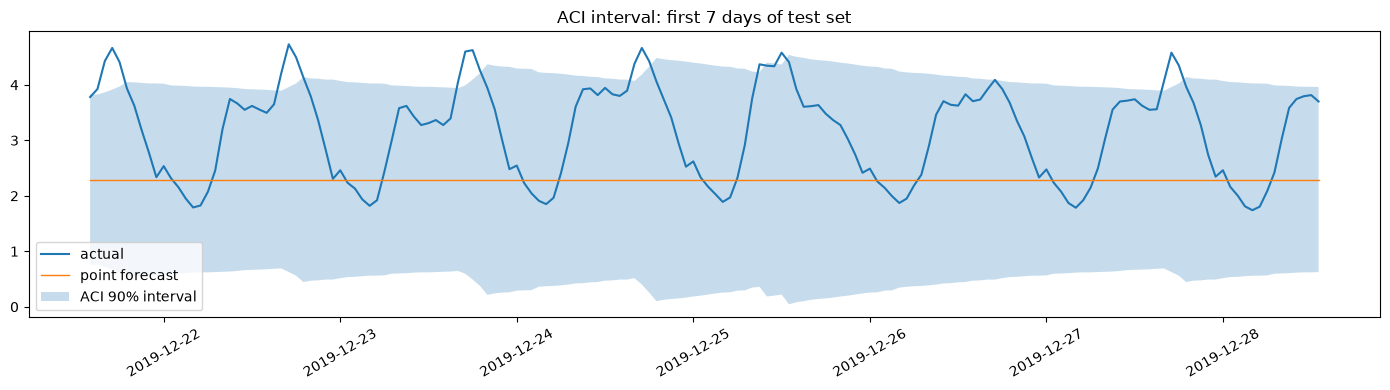

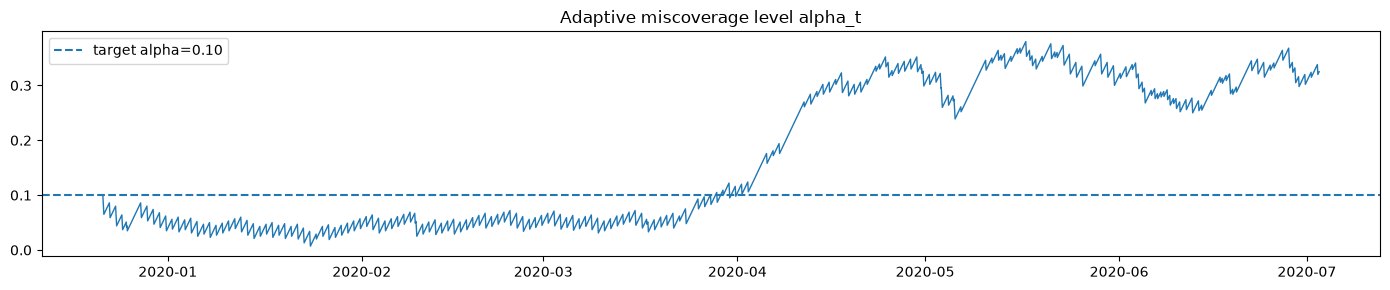

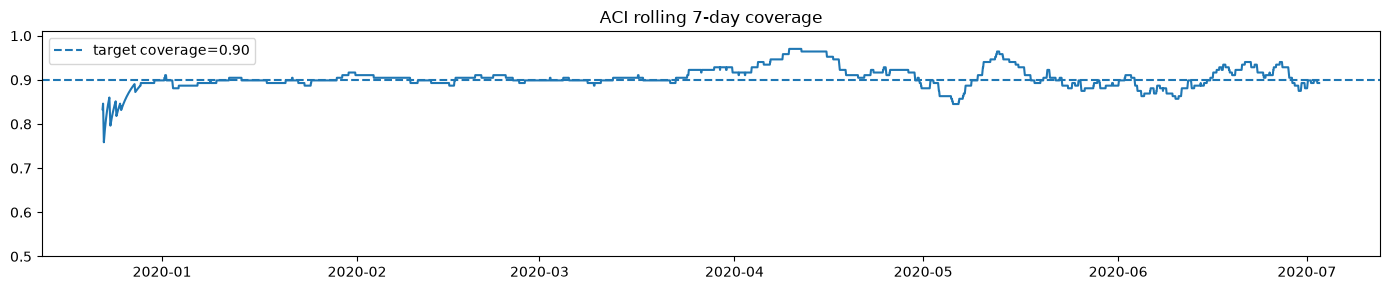

In [9]:
test_time = pd.to_datetime(times[test_idx])
n_plot = min(24*7, len(test_idx))
sl = slice(0,n_plot)

fig, ax = plt.subplots(figsize=(14,4))
ax.plot(test_time[sl], y_test[sl], label="actual", lw=1.5)
ax.plot(test_time[sl], pred_test[sl], label="point forecast", lw=1.0)
ax.fill_between(test_time[sl], aci["lower"][sl], aci["upper"][sl], alpha=0.25, label="ACI 90% interval")
ax.set_title("ACI interval: first 7 days of test set")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14,3))
ax.plot(test_time, aci["alpha_t"], lw=1)
ax.axhline(ALPHA_TARGET, ls="--", label="target alpha=0.10")
ax.set_title("Adaptive miscoverage level alpha_t")
ax.legend()
plt.tight_layout()
plt.show()

covered = ((y_test>=aci["lower"])&(y_test<=aci["upper"])).astype(float)
rolling_cov = pd.Series(covered, index=test_time).rolling(24*7, min_periods=24).mean()

fig, ax = plt.subplots(figsize=(14,3))
ax.plot(rolling_cov.index, rolling_cov.values)
ax.axhline(TARGET_COVERAGE, ls="--", label="target coverage=0.90")
ax.set_ylim(0.5,1.01)
ax.set_title("ACI rolling 7-day coverage")
ax.legend()
plt.tight_layout()
plt.show()

## 9. 从这篇复现迁移到我们自己的课题

这里仍然是：

```text
single-horizon
one-hour-ahead
one alpha state
```

后续主课题会变成：

```text
48-step multi-horizon net-load forecasting
→ horizon-wise ACI
→ risk scenarios
→ CVaR rolling BESS dispatch
→ AC grid value
```

即每个 horizon 分别维护自己的校准状态：

`alpha[t,1], alpha[t,2], ..., alpha[t,48]`

这个 Notebook 的目的，就是先把 **point forecast → residual → conformal interval → ACI feedback → coverage/width trade-off** 跑懂。